# Example spot-variation FCS Genoa Instruments PRISM

Load packages

In [1]:
from brighteyes_ffs.fcs.fcs2corr import fcs_load_and_corr_split as correlate
from brighteyes_ffs.fcs.fcs_fit import fit_corr, fcs_fit
from brighteyes_ffs.fcs.fcs_analytical import fcs_analytical, fcs_dualfocus_c
from brighteyes_ffs.fcs.filter_g import good_chunks_from_g_obj as good_chunks_idx
from brighteyes_ffs.fcs.get_fcs_info import get_metafile_from_file, get_file_info
from brighteyes_ffs.fcs.meas_to_count import mat2h5
from brighteyes_ffs.fcs.plots import plot_timetrace, plot_corrs, plot_corrs_av, plot_corrs_fit, plot_difflaw
from brighteyes_ffs.fcs.plot_corrs_scheme import plot_correlations_microimage
from brighteyes_ffs.fcs.plot_fingerprint import plot_fingerprint7x7
from brighteyes_ffs.fcs_gui.read_ffs import read_g_from_ffs
from brighteyes_ffs.tools.fit_curve import fit_curve
from brighteyes_ffs.tools.stokes_einstein import stokes_einstein
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np

File name and correlation options to calculate.

list_of_g is a list of correlations to calculate. Options are
* predefined keywords, such as 'central', 'sum3', 'sum5' for channel 12, sum3x3, and sum5x5, respectively
* integers for the autocorrelation of a single channel, e.g., 12 for the central element ACF
* define the ACF of a custom sum of detector elements as a string starting with C, e.g., 'C6+7+8+11+12+13+16+17+18' is the same as 'sum3'
* define the CCF as a string starting with 'x' followed by the two channels to cross-correlate, e.g., 'x0512' for the CCF between elements 5 and 12

In [2]:
file = r'D:\ffs_data\20250716_095445_253.mat'
list_of_g = ['prismcentral', 'prismsum3', 'prismsum5', 'prismsum7']
algorithm = 'multipletau' #'multipletau' for time-domain calculation, 'wiener-khinchin' for fft based calculation
accuracy = 20 # the higher this number, the more points the correlation will have
chunksize = 1 # split the data in segments of this length (in seconds) and calculate the ACF for each segment separately
time_trace = True # return also the intensity time trace

In [3]:
fname_h5 = mat2h5(file) # convert to h5. NOTE: this is not absolutely necessary here, but will be done automatically when calculating G
file = fname_h5

In [4]:
mdata = get_file_info(file)

## Calculate correlations

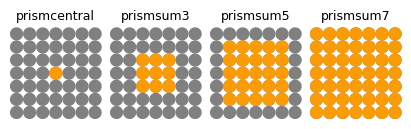

In [5]:
plot_correlations_microimage('7x7', list_of_g, list_of_g, averaging=None, figsize=(4,3))

In [6]:
G, time_trace = correlate(file, list_of_g=list_of_g, algorithm=algorithm, accuracy=accuracy, split=chunksize, time_trace=True, print_info=False)

### Plot time-trace and correlations

The time-trace is a compressed data set of max. 1000 time points per channel. Depending on the chunksize, some padded zeros may appear at the end of the time trace due to rounding errors.

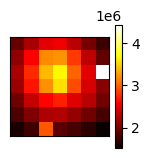

In [7]:
plot_fingerprint7x7(time_trace, figsize=(1.6,1.6))

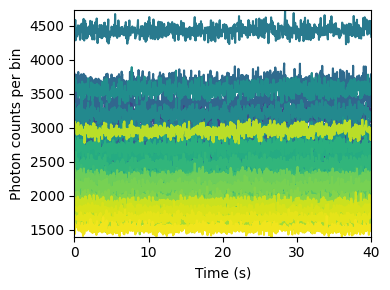

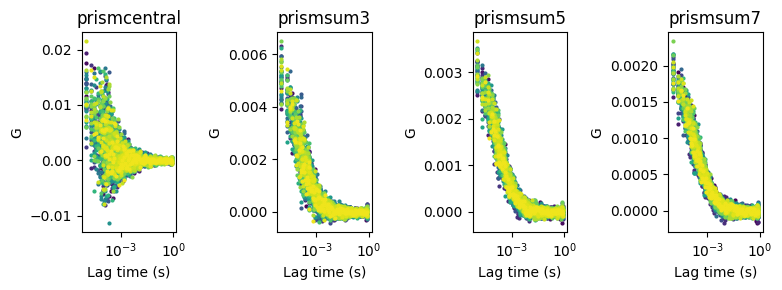

In [7]:
plot_timetrace(time_trace, mdata.duration, figsize=(4,3), cmap='viridis', return_fig=False)
plot_corrs(G, figsize=(8,3), cmap='viridis', return_fig=False)

### Average over good chunks

Some chunks look bad. Write a list with the good chunks only and average over those. The good chunks can be found automatically (beta version) by looking at the sum5 correlation and accepting only the 66 percent best correlations.
Good chunks are shown in grey, bad in red, average of good chunks in black.

In [17]:
idx = good_chunks_idx(G, filt='prismsum7', f_acc=0.80) # look at the sum7 and accept 66 percent
G.good_chunks = idx # average good chunks

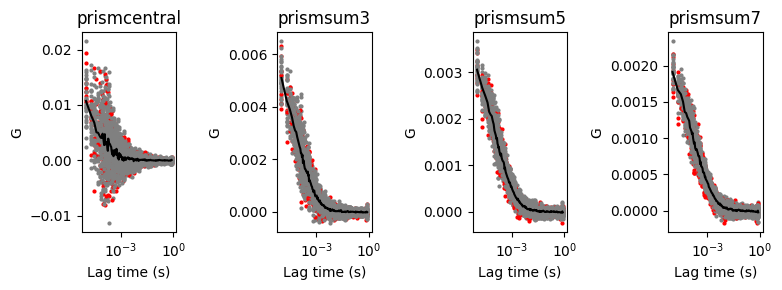

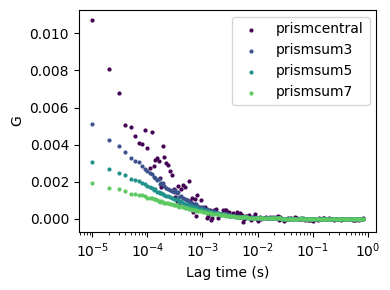

In [18]:
plot_corrs(G, good_chunks_only=True, figsize=(8,3), return_fig=False)
plot_corrs_av(G, good_chunks_only=True, figsize=None, cmap='viridis', return_fig=False)

## Fit correlations

### Fit 1 component 3D diffusion Gaussian volume

For fitmodel = fcs_analytical, the order of the parameters for fitting is
* N: number of particles in focal volume [dim.less]
* tauD: diffusion time species 1 [s]
* SF: shape factor [dim.less]
* offset  [dim.less]

In [19]:
start_idx = 2 # start index of the fit
stop_idx = 1000 # stop index

# N, tauD, SF, offset
fit_info = [True, True, False, False] # fit N and tauD (we fit with one component)
lBounds  = [0, 0, 0, 0] # lower bounds for all parameters
uBounds  = [1e6, 1e6, 1e6, 1e6] # upper bounds for all parameters
param    = [1.0, 1e-3, 5, 0] # starting values for all parameters

Gall, tau, Gstd = G.get_av_corrs(G.list_of_g_out, good_chunks_only=True)
Gall = Gall[start_idx:stop_idx,:]
tau = tau[start_idx:stop_idx]

fitresults = []
for i in range(len(list_of_g)):
    fitresult = fit_corr(Gall[:, i], tau, fit_info, param, lower_bounds=lBounds, upper_bounds=uBounds, fitmodel=fcs_analytical)
    fitresults.append(fitresult)

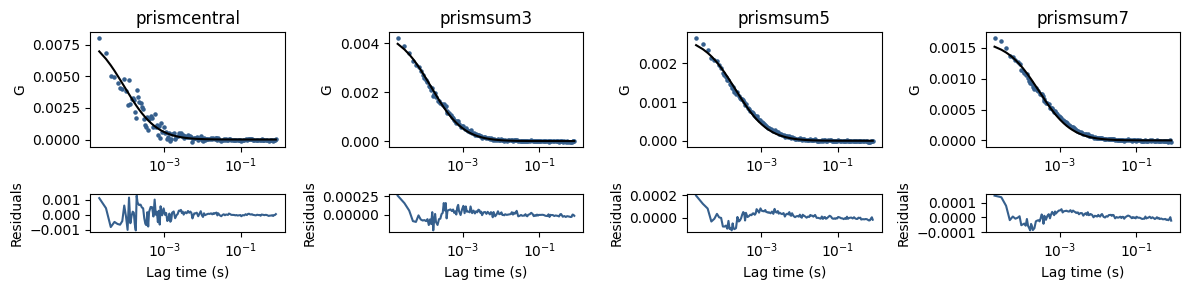

In [20]:
plot_corrs_fit(Gall, tau, list_of_g, fitresults, figsize=None, size=5, return_fig=False)

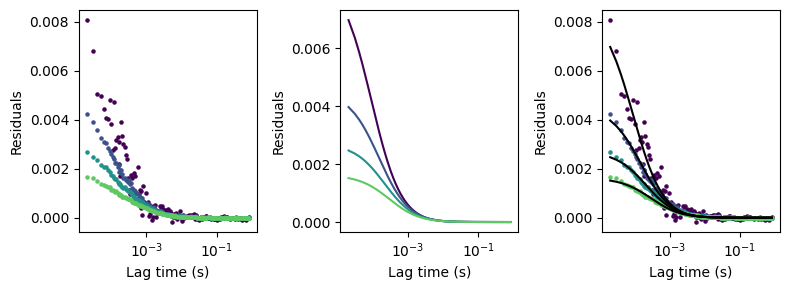

In [21]:
plot_corrs_fit(Gall, tau, list_of_g, fitresults, figsize=None, size=5, return_fig=False, plot_3_col=True)

In [22]:
for i, corr in enumerate(list_of_g):
    fitresult = fitresults[i]
    print(corr)
    print(f"N = {fitresult.x[0]:.2f}")
    print(f"tau_D = {1e3*fitresult.x[1]:.2f} ms\n")
# fitresult.fun

prismcentral
N = 116.73
tau_D = 0.09 ms

prismsum3
N = 221.36
tau_D = 0.15 ms

prismsum5
N = 369.22
tau_D = 0.21 ms

prismsum7
N = 616.10
tau_D = 0.29 ms



### Optional
To manually plot the correlation curves and fits, use

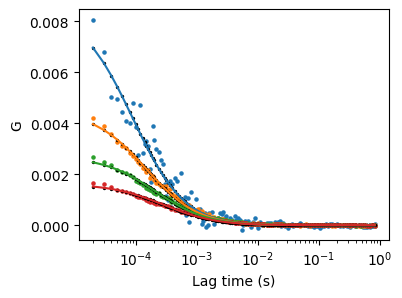

In [23]:
plt.figure(figsize=(4,3))
for i in range(len(list_of_g)):
    fitresult = fitresults[i]
    plt.scatter(tau, Gall[:, i], s=5) # raw data
    plt.plot(tau, fcs_analytical(tau, *fitresult.x)) # first option to plot the fit
    plt.scatter(tau, Gall[:, i] - fitresult.fun, c='k', s=2) # second option to plot the fit
plt.xlabel('Lag time (s)')
plt.ylabel('G')
plt.xscale('log')

### Fit diffusion law

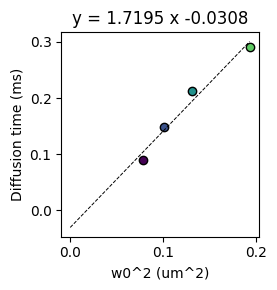

In [24]:
taufit = [1e3*fitresult.x[1] for fitresult in fitresults] # ms
w0 = 1e-3*np.asarray([280, 318, 362, 439]) # um
plot_difflaw(taufit, w0, figsize=None, cmap='viridis', return_fig=False)

In [25]:
T = 293  # temperature in K
visc = 1e-3  # viscosity in Pa.s

for i in range(4):
    D = 1e12 * (1e-6 * w0[i])**2 / (4 * 1e-3 * taufit[i])
    diameter = 1e9 * stokes_einstein(1e-12 * D, T, visc)
    print(f"Diffusion coefficient: {D:.2f} um^2/s --> diameter: {diameter:.2f} nm")

Diffusion coefficient: 218.18 um^2/s --> diameter: 1.97 nm
Diffusion coefficient: 170.07 um^2/s --> diameter: 2.52 nm
Diffusion coefficient: 154.06 um^2/s --> diameter: 2.79 nm
Diffusion coefficient: 165.47 um^2/s --> diameter: 2.59 nm


## Global fit

NOTE: for spot-variation FCS, the diffusion coefficient and w0 are not independent parameters.

In [27]:
# fit model: fcs_dualfocus_c
# order of parameters:
#               c      D      w0     SF     rhox   rhoy   vx     vy     offset
# units:        /um^3  um^2/s um     -      um     um     um/s   um/s   -
fit_info     = [True,  True,  False, False, False, False, False, False, False] # should the parameter be fitted?
global_param = [True,  True,  False, False, False, False, True,  True,  False] # should the parameter be the same for every curve?
lbounds      = [1e-12, 1e-12, 1e-12, 1e-12, 0, 0,  0, 0, -1e-12] # lower bounds in case of fit
ubounds      = [1e12,  1e12,  1e12,  1e12,  1e12,  1e12,  1e12,  1e12,  1e12]  # upper bounds in case of fit
param_10     = [1e18,  1e-12, 1e-6,     1,  1e-6,  1e-6,  1,     1,     1]

# starting values for w0 for each of the curves. Note: if this is a fit parameter, it may be set to any reasonable starting value
w0_all       = [0.220, 0.260, 0.314, 0.380]

param = np.zeros((len(fit_info), len(G.list_of_g_out)))
for i, corr in enumerate(G.list_of_g_out):
    param[:, i] = np.asarray([1, 1, w0_all[i], 5.0, 0, 0, 0, 0, 0]) # starting values

G_all, tau, G_std = G.get_av_corrs(G.list_of_g_out)
G_all = G_all[start_idx:stop_idx,:]
tau = tau[start_idx:stop_idx]

fitresult = fit_corr(G_all, tau, fit_info, param, global_param=global_param, param_factors10=param_10,
                     lower_bounds=lBounds, upper_bounds=uBounds, fitmodel=fcs_dualfocus_c)

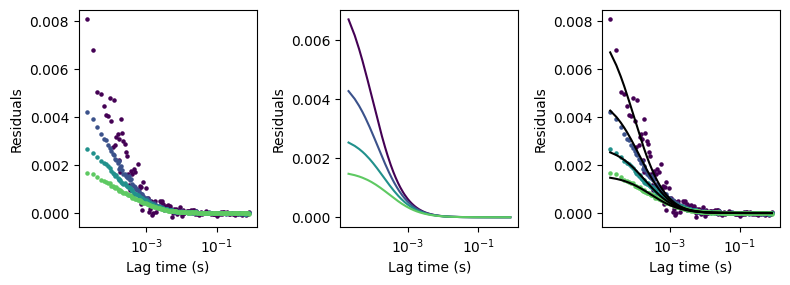

In [28]:
plot_corrs_fit(G_all, tau, list_of_g, fitresult, figsize=None, size=5, return_fig=False, plot_3_col=True)

In [29]:
fitresult.x

array([[4.15686669e+02, 4.15686669e+02, 4.15686669e+02, 4.15686669e+02],
       [1.25083348e+02, 1.25083348e+02, 1.25083348e+02, 1.25083348e+02],
       [2.20000000e-01, 2.60000000e-01, 3.14000000e-01, 3.80000000e-01],
       [5.00000000e+00, 5.00000000e+00, 5.00000000e+00, 5.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00]])